In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Task 1: Data Collection

In [2]:
df = pd.read_csv('Indian Ecommerce Dataset.csv')

In [3]:
df.head()

,Product_ID,Product_Name,Category,Brand,Price,Rating,Description,Seller,City,State,Stock_Quantity,Discount_Percentage
0,P00001,Boat Electronic Model 509,Electronics,Boat,72396,3.5,Boat electronics product with premium features.,Seller_72,Mumbai,West Bengal,379,69
1,P00002,Apple Mobile Model 7012,Mobiles,Apple,8630,3.1,Apple mobiles product with premium features.,Seller_112,Bengaluru,Tamil Nadu,308,3
2,P00003,Samsung Home Appliance Model 9028,Home Appliances,Samsung,110273,3.4,Samsung home appliances product with premium f...,Seller_302,Hyderabad,Gujarat,445,0
3,P00004,Asus Laptop Model 5674,Laptops,Asus,73141,3.3,Asus laptops product with premium features.,Seller_491,Chennai,Maharashtra,47,48
4,P00005,Realme Mobile Model 5735,Mobiles,Realme,69641,4.6,Realme mobiles product with premium features.,Seller_374,Ahmedabad,Tamil Nadu,63,48


In [4]:
df.tail()

,Product_ID,Product_Name,Category,Brand,Price,Rating,Description,Seller,City,State,Stock_Quantity,Discount_Percentage
19995,P19996,Sony Electronic Model 8713,Electronics,Sony,92336,3.1,Sony electronics product with premium features.,Seller_304,Delhi,West Bengal,94,25
19996,P19997,Dell Laptop Model 9146,Laptops,Dell,142596,5.0,Dell laptops product with premium features.,Seller_184,Chennai,Gujarat,65,33
19997,P19998,Vivo Mobile Model 2092,Mobiles,Vivo,6126,4.4,Vivo mobiles product with premium features.,Seller_441,Chennai,Karnataka,429,55
19998,P19999,Puma Clothin Model 2699,Clothing,Puma,145291,4.4,Puma clothing product with premium features.,Seller_173,Pune,Delhi,166,67
19999,P20000,OnePlus Mobile Model 5858,Mobiles,OnePlus,72986,3.7,OnePlus mobiles product with premium features.,Seller_493,Delhi,Karnataka,26,20


### Task 2: Data Cleaning 

In [5]:
df.isnull().sum()

Product_ID             0
Product_Name           0
Category               0
Brand                  0
Price                  0
Rating                 0
Description            0
Seller                 0
City                   0
State                  0
Stock_Quantity         0
Discount_Percentage    0
dtype: int64

In [6]:
print(f"duplicate records: {df.duplicated().sum()}")

duplicate records: 0


In [7]:
df.dtypes

Product_ID              object
Product_Name            object
Category                object
Brand                   object
Price                    int64
Rating                 float64
Description             object
Seller                  object
City                    object
State                   object
Stock_Quantity           int64
Discount_Percentage      int64
dtype: object

###  Task 3: Exploratory Data Analysis (EDA) 

In [8]:
print(f"Total number of products: {df['Product_Name'].nunique()}")

Total number of products: 19298


In [9]:
print(f"Total number of categories: {df['Category'].nunique()}")

Total number of categories: 6


In [10]:
top_10_brands = df['Brand'].value_counts().head(10)
print(top_10_brands)

Brand
Puma         1525
Samsung      1406
Adidas        855
Nike          850
LG            841
Whirlpool     829
Noise         827
Bata          823
Sony          798
Boat          776
Name: count, dtype: int64


In [11]:
print(f"Average product price: \n {df.groupby('Category')['Price'].mean()}")

Average product price: 
 Category
Clothing           76749.566677
Electronics        74724.176508
Footwear           73764.368000
Home Appliances    75560.968069
Laptops            74738.333928
Mobiles            74760.865745
Name: Price, dtype: float64


In [12]:
print(f"Highest-rated products: \n {df.loc[df['Rating'].idxmax()]}")

Highest-rated products: 
 Product_ID                                                    P00093
Product_Name                                Xiaomi Mobile Model 9524
Category                                                     Mobiles
Brand                                                         Xiaomi
Price                                                           5737
Rating                                                           5.0
Description            Xiaomi mobiles product with premium features.
Seller                                                    Seller_345
City                                                       Hyderabad
State                                                     Tamil Nadu
Stock_Quantity                                                    20
Discount_Percentage                                               22
Name: 92, dtype: object


#### Number of Products by Category

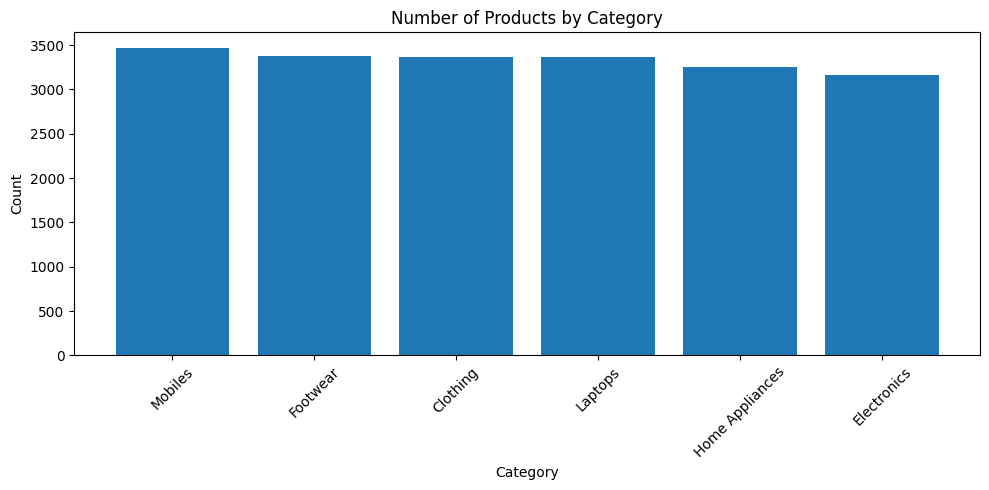

In [38]:

category_count = df["Category"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(category_count.index, category_count.values)
plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Product Distribution by State

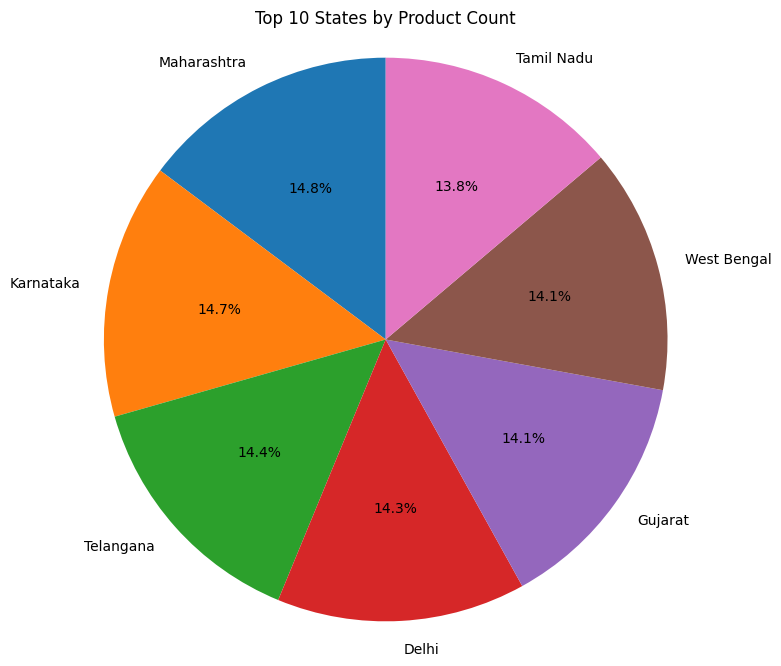

In [29]:
state_count = df["State"].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(
    state_count,
    labels=state_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 States by Product Count")
plt.axis("equal")
plt.show()

 #### how product prices are distributed

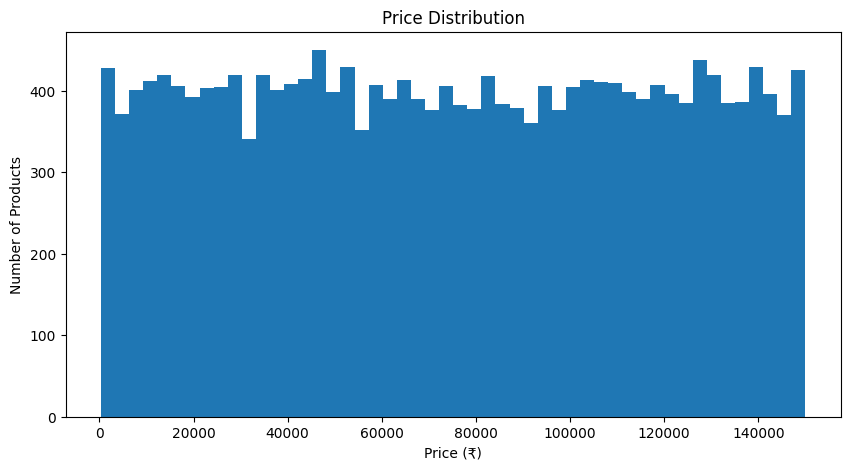

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Products")

plt.show()

In [26]:
df.columns


Index(['Product_ID', 'Product_Name', 'Category', 'Brand', 'Price', 'Rating',
       'Description', 'Seller', 'City', 'State', 'Stock_Quantity',
       'Discount_Percentage', 'Features'],
      dtype='object')

### Task 4: Feature Engineering 

In [14]:
df['Features'] = df['Category'] +', '+ df['Brand'] +', '+ df['Description']

In [15]:
df.head()

,Product_ID,Product_Name,Category,Brand,Price,Rating,Description,Seller,City,State,Stock_Quantity,Discount_Percentage,Features
0,P00001,Boat Electronic Model 509,Electronics,Boat,72396,3.5,Boat electronics product with premium features.,Seller_72,Mumbai,West Bengal,379,69,"Electronics, Boat, Boat electronics product wi..."
1,P00002,Apple Mobile Model 7012,Mobiles,Apple,8630,3.1,Apple mobiles product with premium features.,Seller_112,Bengaluru,Tamil Nadu,308,3,"Mobiles, Apple, Apple mobiles product with pre..."
2,P00003,Samsung Home Appliance Model 9028,Home Appliances,Samsung,110273,3.4,Samsung home appliances product with premium f...,Seller_302,Hyderabad,Gujarat,445,0,"Home Appliances, Samsung, Samsung home applian..."
3,P00004,Asus Laptop Model 5674,Laptops,Asus,73141,3.3,Asus laptops product with premium features.,Seller_491,Chennai,Maharashtra,47,48,"Laptops, Asus, Asus laptops product with premi..."
4,P00005,Realme Mobile Model 5735,Mobiles,Realme,69641,4.6,Realme mobiles product with premium features.,Seller_374,Ahmedabad,Tamil Nadu,63,48,"Mobiles, Realme, Realme mobiles product with p..."


In [16]:

df.to_csv('new_data.csv' , index= False)

### Task 5: Text Vectorization 

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer(stop_words = 'english')

In [19]:
tfidf_matrix = tfidf.fit_transform(df['Features'])

In [20]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 103929 stored elements and shape (20000, 37)>

### Task 6: Similarity Matrix 

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
cosine_sim = cosine_similarity(tfidf_matrix , tfidf_matrix)

### Task 7: Recommendation Function 

In [23]:
def recommend_products(product_name,  cosine_sim=cosine_sim, df=df):

    idx = df[df['Product_Name'] == product_name].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:6]
    product_indices = [i[0] for i in sim_scores]

    return df[['Product_Name','Category','Brand','Price','Rating']].iloc[product_indices]

### Task 8 & 9 : User Input &  Exception Handling  

In [24]:
try:
    Product_name = input("Enter Product Name:")
    print(recommend_products(Product_name))
except TypeError:
    print("Give the valid Product Name.")
except NameError:
    print("Product Not Found, Give the Valid Product Name.")
except IndexError:
    print("Product Not Found, Give the Valid Product Name.")

Enter Product Name: Realme Mobile Model 5735


                 Product_Name Category   Brand   Price  Rating
199  Realme Mobile Model 9177  Mobiles  Realme   97006     3.9
200  Realme Mobile Model 6623  Mobiles  Realme  125778     4.1
211  Realme Mobile Model 6393  Mobiles  Realme  109910     3.5
239  Realme Mobile Model 6384  Mobiles  Realme   62039     3.9
386   Realme Mobile Model 428  Mobiles  Realme   83848     3.5
